# Direct evaluation of the semantic segmentation performance
This script is used to test the Maskclip and Opengraph perception front-end modules directly on the 100 GT images to compare the results with/without the filtering through the scene graph

## Imports and load GT images

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Global seed set to 0


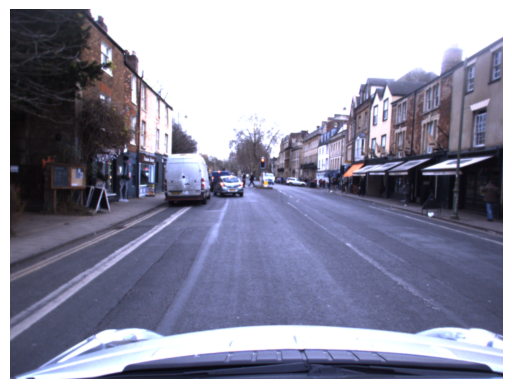

In [1]:
import sys
sys.path.append('/workspaces/collaborative-scene-graphs/src/curb_projection/src')
from curb_projection.maskclip_semseg import MaskCLIPSemSeg
from curb_projection.opengraph_semseg import OpenGraphSemSeg

import rospy
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

gt_image_dir = "/workspaces/collaborative-scene-graphs/src/curb_metrics/data/semseg_gt/test"

gt_image_files = [os.path.join(gt_image_dir, f) for f in os.listdir(gt_image_dir) if f.endswith('.png')]
gt_image_files.sort()
gt_images = [cv2.imread(f, cv2.IMREAD_UNCHANGED) for f in gt_image_files]

# define function to show image as plt
def show_image(img):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

show_image(gt_images[2])

In [2]:

import json
gt_dataset = "/workspaces/collaborative-scene-graphs/src/curb_metrics/data/semseg_gt/robotcar-labeling-maryam-v0.43.json"
with open(gt_dataset, "r") as f:
    gt_json = json.load(f)

cats_json = gt_json["dataset"]["task_attributes"]["categories"]

category2id = {c["name"]: c["id"] for c in cats_json}
category2id['traffic sign']

13

## load Model

In [15]:
model = 'og'
if model == 'mc':
    rospy.set_param('~maskclip_prompt', "tree,side walk or footpath or pavement,road,traffic light,traffic sign,vehicle,building,other,house")
    semseg = MaskCLIPSemSeg()
else:
    rospy.set_param('~weights_folder', "/workspaces/collaborative-scene-graphs/src/curb_projection/saved_models")
    rospy.set_param('~concept_weights', "tap_concept_weights_cityscapes_19.pkl")
    rospy.set_param('~use_tag2text', False)
    semseg = OpenGraphSemSeg()

final text_encoder_type: bert-base-uncased


## Eval

In [16]:
from tqdm import tqdm
from time import sleep

out_mc = "/workspaces/collaborative-scene-graphs/src/curb_metrics/data/semseg_pred/maskclip_raw_pred"
out_og = "/workspaces/collaborative-scene-graphs/src/curb_metrics/data/semseg_pred/opengraph_raw_pred"

out = out_mc if model == 'mc' else out_og

out_json = os.path.join(out, "predictions.json")
out_dir = os.path.join(out, "predictions")
os.makedirs(out_dir, exist_ok=True)

annotations = []
for img, file_name in tqdm(zip(gt_images, gt_image_files)):
    annotation = {
        "file_name": file_name.split("/")[-1],
        "image_id": file_name.split("/")[-1].split(".")[0]
    }
    masks, classes, scores = semseg.process_batch([img])[0]
    segments_info = []
    assert len(masks) < 255, "Too many masks"
    segmentation_bitmap = np.zeros(
        (masks[0].shape[0], masks[0].shape[1], 3), dtype=np.uint8
    )
    id  = 1
    for i, c in enumerate(classes):
        mask = masks[i]
        score = scores[i]
        if c == 'traffic sign' or c == 'traffic light':
            segments_info.append({
                "id": id,
                "category_id": category2id[c],
                "area": int(np.sum(mask)),
                "iscrowd": 0,
                "certainty": float(score),
                "n_obs": 3,
                "occlusion_ratio": 0.0,
                "obs_kfs": [],
                "depth": 0.0,
                "category_name": c
            })
            segmentation_bitmap[:,:,2][mask > 0] = id
            id += 1
    vis_img = cv2.addWeighted(img, 0.5, ((segmentation_bitmap>0).astype(np.uint8) * 255), 0.5, 0)
    annotation["segments_info"] = segments_info
    cv2.imwrite(os.path.join(out_dir, annotation["image_id"] + ".vis.png"), vis_img)
    cv2.imwrite(os.path.join(out_dir, annotation["image_id"] + ".png"), segmentation_bitmap)
    annotations.append(annotation)
    sleep(0.2)

json.dump({"annotations": annotations}, open(out_json, "w"))


100it [00:51,  1.95it/s]


# actual evaluation against semseg ground truth

In [12]:

import panoptic_metrics

gt_json = '/workspaces/collaborative-scene-graphs/src/curb_metrics/data/semseg_gt/robotcar-labeling-v1.0.coco.json'
gt_dir = gt_json.split('.json')[0]

out_mc_json = "/workspaces/collaborative-scene-graphs/src/curb_metrics/data/semseg_pred/maskclip_raw_pred/predictions.json"
out_mc_dir = out_mc_json.split('.json')[0]

result_all = panoptic_metrics.evaluatePanoptic(gt_json, gt_dir, out_mc_json, out_mc_dir, resultsFile=None, min_obs_agents=0, max_occl=100.0)

Evaluation panoptic segmentation metrics:
Ground truth:
	Segmentation folder: /workspaces/collaborative-scene-graphs/src/curb_metrics/data/semseg_gt/robotcar-labeling-v1.0.coco
	JSON file: /workspaces/collaborative-scene-graphs/src/curb_metrics/data/semseg_gt/robotcar-labeling-v1.0.coco.json
Prediction:
	Segmentation folder: /workspaces/collaborative-scene-graphs/src/curb_metrics/data/semseg_pred/maskclip_raw_pred/predictions
	JSON file: /workspaces/collaborative-scene-graphs/src/curb_metrics/data/semseg_pred/maskclip_raw_pred/predictions.json
evaluating for 100 images
Number of cores: 8, images per core: 13
Category      |  MIOU      P      R     PQ     SQ     RQ
traffic light | 27.417  42.308  20.561    7.6   27.4   27.7
traffic sign  | 53.830  80.000  7.547    7.4   53.8   13.8
-----------------------------------------------------------------------
Category      |  MIOU      P      R     PQ     SQ     RQ
All           | 40.624  61.154  14.054    7.5   40.6   20.7     2
-------------

In [17]:

out_og_json = "/workspaces/collaborative-scene-graphs/src/curb_metrics/data/semseg_pred/opengraph_raw_pred/predictions.json"
out_og_dir = out_og_json.split('.json')[0]

result_all = panoptic_metrics.evaluatePanoptic(gt_json, gt_dir, out_og_json, out_og_dir, resultsFile=None, min_obs_agents=0, max_occl=100.0)

Evaluation panoptic segmentation metrics:
Ground truth:
	Segmentation folder: /workspaces/collaborative-scene-graphs/src/curb_metrics/data/semseg_gt/robotcar-labeling-v1.0.coco
	JSON file: /workspaces/collaborative-scene-graphs/src/curb_metrics/data/semseg_gt/robotcar-labeling-v1.0.coco.json
Prediction:
	Segmentation folder: /workspaces/collaborative-scene-graphs/src/curb_metrics/data/semseg_pred/opengraph_raw_pred/predictions
	JSON file: /workspaces/collaborative-scene-graphs/src/curb_metrics/data/semseg_pred/opengraph_raw_pred/predictions.json
evaluating for 100 images
Number of cores: 8, images per core: 13


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

WARN: In the PRED image with ID 1547475397107891 the following segment IDs [1] are presented in JSON and not presented in PNG.
WARN: In the PRED image with ID 1547476711889736 the following segment IDs [4] are presented in JSON and not presented in PNG.
WARN: In the PRED image with ID 1547475346856662 the following segment IDs [1, 2] are presented in JSON and not presented in PNG.
WARN: In the PRED image with ID 1547476940832838 the following segment IDs [1] are presented in JSON and not presented in PNG.
WARN: In the PRED image with ID 1547475517423286 the following segment IDs [7] are presented in JSON and not presented in PNG.
Category      |  MIOU      P      R     PQ     SQ     RQ
traffic light | 81.267  90.196  42.991   47.3   81.3   58.2
traffic sign  | 75.590  92.857  24.299   29.1   75.6   38.5
-----------------------------------------------------------------------
Category      |  MIOU      P      R     PQ     SQ     RQ
All           | 78.429  91.527  33.645   38.2   78.4   4